# Modeling Urban Traffic Flow Using NYC Taxi Data

This project models the relationship between traffic density and vehicle speed using NYC taxi data. 

We begin with a classical linear traffic model and compare it to observed data. Finding that the linear model does not fit well, we introduce a nonlinear exponential model and analyze system behavior.

The goal is to:
- Understand how traffic speed changes with density  
- Model flow as a nonlinear system  
- Identify a critical density threshold where efficiency is maximized  

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')
from scipy.optimize import curve_fit
from datetime import date

## Data Preparation

We aggregate taxi trips by hour to estimate:
- Average speed
- Demand (used as a proxy for density)

Note: This density is a normalized trip-density proxy, not physical road density.

In [7]:
# load data
df1 = pd.read_parquet('data/yellow_tripdata_2022-08.parquet')
df2 = pd.read_parquet('data/yellow_tripdata_2022-09.parquet')
df3 = pd.read_parquet('data/yellow_tripdata_2022-10.parquet')

# combine
df = pd.concat([df1, df2, df3], ignore_index=True)

# datetime conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# trip duration
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# time features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date


# filter bad data
df = df[
    (df['trip_duration'] > 1) &
    (df['trip_duration'] < 120) &
    (df['trip_distance'] > 0)
]

# only looking at values from August to October
df = df[
    (df['pickup_date'] >= date(2022, 8, 1)) &
    (df['pickup_date'] <= date(2022, 10, 31))
]

print(df.shape)

(9784711, 23)


In [8]:
# create density + speed
df_hourly = df.groupby('pickup_hour').agg({
    'trip_distance': 'mean',
    'trip_duration': 'mean'
}).rename(columns={
    'trip_distance': 'avg_distance',
    'trip_duration': 'avg_duration'
})

# speed (mph)
df_hourly['speed_mph'] = df_hourly['avg_distance'] / (df_hourly['avg_duration'] / 60)

# density proxy = number of trips per hour
density = df.groupby('pickup_hour').size()
df_hourly['density'] = density

df_hourly.head()

,avg_distance,avg_duration,speed_mph,density
pickup_hour,,,,
0,6.177717,14.622416,25.348960,280823
1,7.205632,13.160402,32.851423,183375
2,9.652968,12.630839,45.854284,124071
3,7.927800,12.777568,37.226801,81428
4,20.527529,14.518101,84.835597,54334


## Speed vs Density

We examine how speed changes as demand increases.

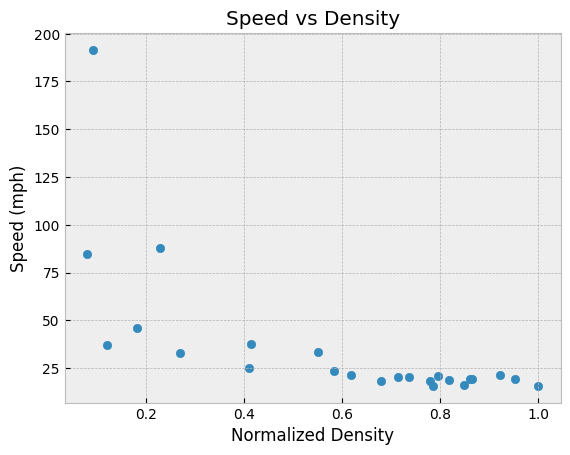

In [9]:
# normalize density (0 to 1)
df_hourly['density_norm'] = df_hourly['density'] / df_hourly['density'].max()

# plot speed vs density
import matplotlib.pyplot as plt

plt.scatter(df_hourly['density_norm'], df_hourly['speed_mph'])
plt.xlabel("Normalized Density")
plt.ylabel("Speed (mph)")
plt.title("Speed vs Density")
plt.show()

Speed decreases as density increases, suggesting congestion effects.

## Linear Traffic Model

We first test a classical linear model relating speed and density using this relation:

$$ v(\rho) = v_{max} (1-\rho), $$

where $v_{max}$ is the maximum observed speed, and $\rho$ is the density.

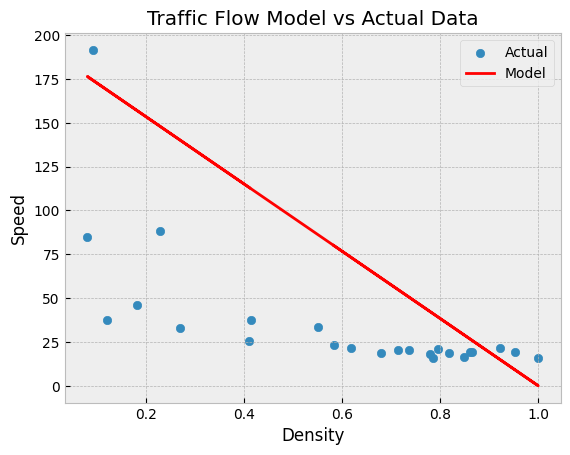

In [18]:
v_max = df_hourly['speed_mph'].max()
rho = df_hourly['density_norm']

df_hourly['model_speed'] = v_max * (1 - rho)


# compare model vs reality
plt.scatter(rho, df_hourly['speed_mph'], label='Actual')
plt.plot(rho, df_hourly['model_speed'], color='red', label='Model')

plt.xlabel("Density")
plt.ylabel("Speed")
plt.title("Traffic Flow Model vs Actual Data")
plt.legend()
plt.show()

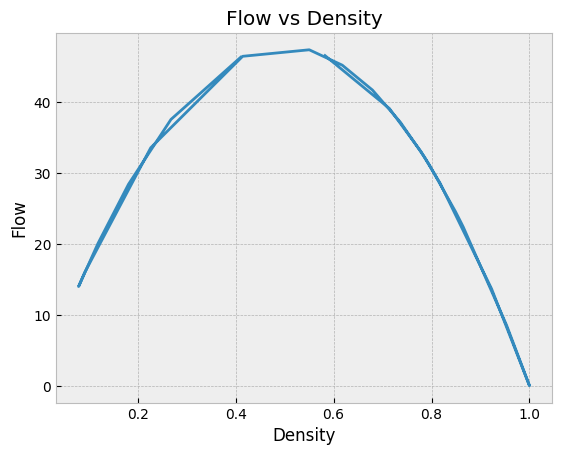

In [19]:
df_hourly['flow'] = df_hourly['density_norm'] * df_hourly['model_speed']

plt.plot(df_hourly['density_norm'], df_hourly['flow'])
plt.xlabel("Density")
plt.ylabel("Flow")
plt.title("Flow vs Density")
plt.show()

The linear model does not align well with observed data, indicating a more complex relationship.

## Nonlinear Model (Underwood)

We fit an exponential model:

$$ v(\rho) = v_f * e^{-k\rho}, $$

Where $v_f$ is the free-flow speed. This better captures the asymptotic decline in speed.

vf_fit: 126.83926040223923
k_fit: 2.7656047436115356


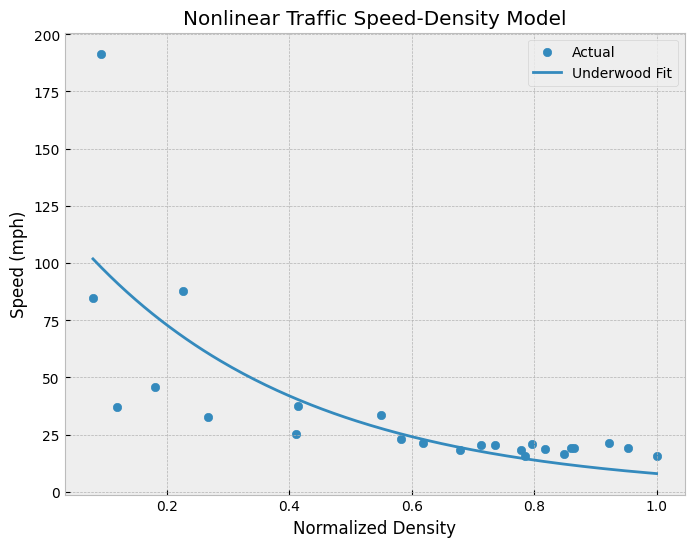

In [20]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# prepare clean arrays
x = df_hourly['density_norm'].astype(float).values
y = df_hourly['speed_mph'].astype(float).values

# remove bad values
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# model
def underwood_model(rho, vf, k):
    return vf * np.exp(-k * rho)

# fit
params, covariance = curve_fit(
    underwood_model,
    x,
    y,
    p0=[y.max(), 1.0],
    maxfev=10000
)

vf_fit, k_fit = params

print("vf_fit:", vf_fit)
print("k_fit:", k_fit)

# smooth curve for plotting
x_smooth = np.linspace(x.min(), x.max(), 200)
y_fit = underwood_model(x_smooth, vf_fit, k_fit)

# plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Actual')
plt.plot(x_smooth, y_fit, label='Underwood Fit')
plt.xlabel("Normalized Density")
plt.ylabel("Speed (mph)")
plt.title("Nonlinear Traffic Speed-Density Model")
plt.legend()
plt.show()

## Model Evaluation

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = underwood_model(x, vf_fit, k_fit)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("RMSE:", rmse)
print("R^2:", r2)

RMSE: 24.88023970517177
R^2: 0.5601716091330435


## Flow Modeling

Traffic flow is defined as:

$$ q(\rho) = \rho * v(\rho) $$

We compute flow using the fitted nonlinear model.

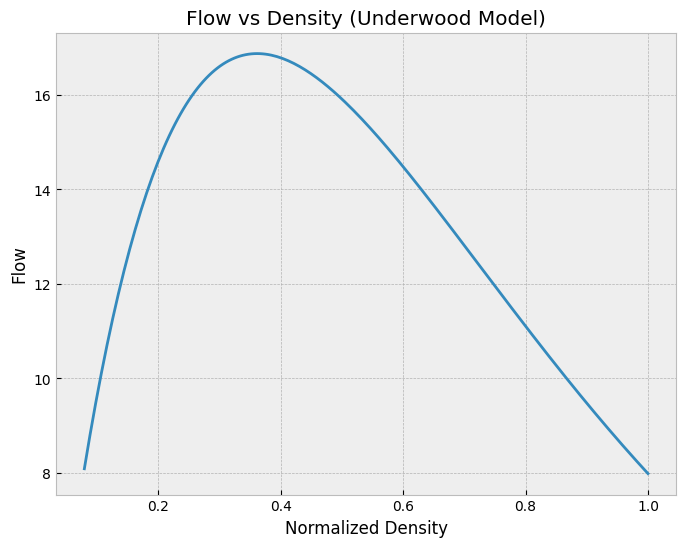

In [22]:
flow_fit = x_smooth * y_fit

plt.figure(figsize=(8, 6))
plt.plot(x_smooth, flow_fit)
plt.xlabel("Normalized Density")
plt.ylabel("Flow")
plt.title("Flow vs Density (Underwood Model)")
plt.show()

## Critical Density

We identify the density at which flow is maximized.

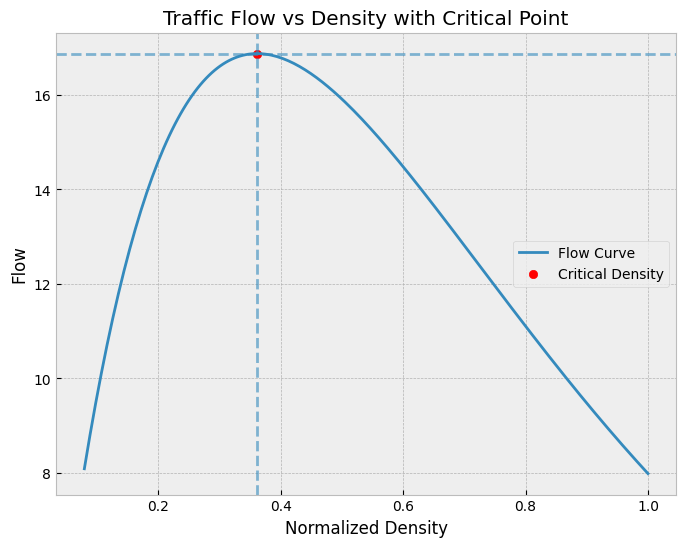

In [23]:
critical_idx = np.argmax(flow_fit)
critical_density = x_smooth[critical_idx]
critical_flow = flow_fit[critical_idx]

plt.figure(figsize=(8, 6))

plt.plot(x_smooth, flow_fit, label='Flow Curve')
plt.scatter(critical_density, critical_flow, color='red', label='Critical Density')

plt.axvline(critical_density, linestyle='--', alpha=0.6)
plt.axhline(critical_flow, linestyle='--', alpha=0.6)

plt.xlabel("Normalized Density")
plt.ylabel("Flow")
plt.title("Traffic Flow vs Density with Critical Point")
plt.legend()

plt.show()